In [10]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTEN

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel("../data/job_classification.ods", engine = "odf", dtype = str)

In [3]:
data = data.dropna(axis = 0)

In [6]:
def filler_location(location):
    result = re.findall("\\,\\s[A-Z]{2}$", location)
    if len(result) > 0:
        return result[0][2:]
    else:
        return location


data["location"] = data["location"].apply(filler_location)

In [7]:
target = "career_level"
x = data.drop(target, axis = 1)
y = data[target]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [11]:
transformers = ColumnTransformer(transformers = [
    ("title", TfidfVectorizer(stop_words="english"), "title"),
    ("location", OneHotEncoder(handle_unknown="ignore"), ["location"]),
    ("description", TfidfVectorizer(stop_words="english", ngram_range=(1,2)), "description"),
    ("function", OneHotEncoder(handle_unknown="ignore"), ["function"]),
    ("industry", TfidfVectorizer(stop_words="english"), "industry")
])

In [12]:
over_sampling = SMOTEN(random_state=42, k_neighbors = 2, sampling_strategy = {
    "managing_director_small_medium_company" : 100,
    "specialist" : 100,
    "director_business_unit_leader" : 100,
    "bereichsleiter" : 1000
})
x_train, y_train = over_sampling.fit_resample(x_train, y_train)
print(y_train.value_counts())

career_level
senior_specialist_or_project_manager      3469
manager_team_leader                       2138
bereichsleiter                            1000
specialist                                 100
director_business_unit_leader              100
managing_director_small_medium_company     100
Name: count, dtype: int64


In [13]:
oversampling_model = Pipeline(
    steps=[
        ("transformers", transformers),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [14]:
oversampling_model.fit(x_train, y_train)

y_over_predict = oversampling_model.predict(x_test)

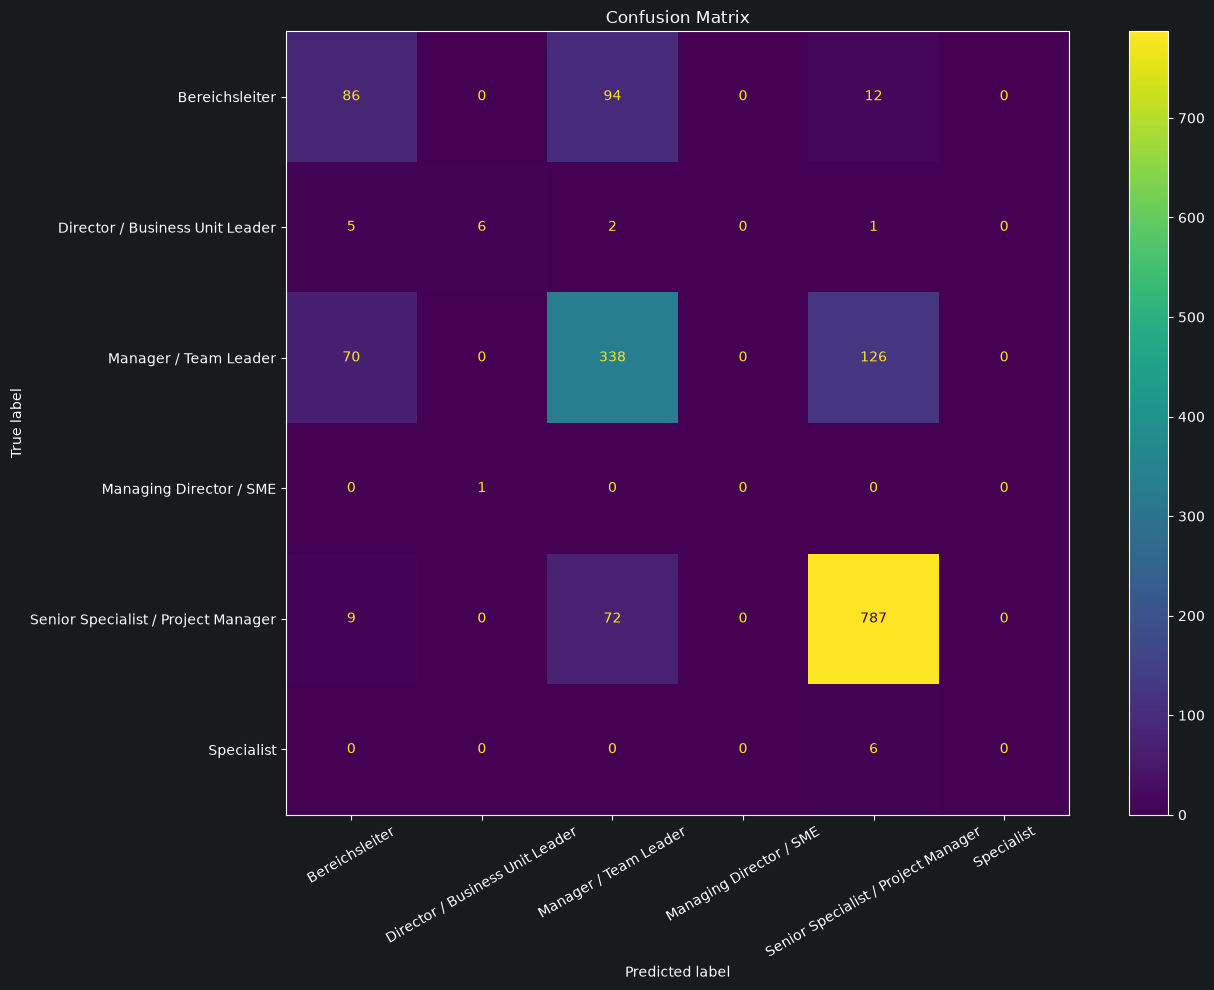

In [20]:
cm = confusion_matrix(y_test, y_over_predict)

labels = [
    "Bereichsleiter",
    "Director / Business Unit Leader",
    "Manager / Team Leader",
    "Managing Director / SME",
    "Senior Specialist / Project Manager",
    "Specialist"
]

fig, ax = plt.subplots(figsize=(14, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=30
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
error_analysis = x_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = y_over_predict

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

errors.head()

,title,location,description,function,industry,actual,predicted
6612,Project Manager,NV,Dimensions:Â·Â Â Â Â Â Â Â Â Direct the Devel...,production_manufacturing,Mining and Quarrying,bereichsleiter,manager_team_leader
742,VP Account Director,IL,Weâ€™re searching for a Vice President/Directo...,marketing,Direct Marketing / CRM,manager_team_leader,bereichsleiter
2049,"Global Director, Sales Excellence",OH,"Key Job Responsibilities:The Global Director, ...",sales,Manufacture of Paper and Printing Products,bereichsleiter,manager_team_leader
7635,"Vice President, Senior Product Manager-Multi A...",CA,Franklin Templeton Investments is a leading gl...,marketing,Investment Banking,manager_team_leader,senior_specialist_or_project_manager
1280,"BK Director, Systems Engineering - Albuquerque...",NM,The Director of Systems Engineering oversees a...,research_development,Air and Space Transport,bereichsleiter,manager_team_leader


In [22]:
confusion_pairs = (
    errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(10)

,actual,predicted,count
6,manager_team_leader,senior_specialist_or_project_manager,126
0,bereichsleiter,manager_team_leader,94
9,senior_specialist_or_project_manager,manager_team_leader,72
5,manager_team_leader,bereichsleiter,70
1,bereichsleiter,senior_specialist_or_project_manager,12
8,senior_specialist_or_project_manager,bereichsleiter,9
10,specialist,senior_specialist_or_project_manager,6
2,director_business_unit_leader,bereichsleiter,5
3,director_business_unit_leader,manager_team_leader,2
4,director_business_unit_leader,senior_specialist_or_project_manager,1


In [23]:
manager_errors = errors[
    (errors["actual"] == "manager_team_leader") &
    (errors["predicted"] == "senior_specialist_or_project_manager")
]

manager_errors[
    ["title", "description", "function", "industry"]
].head(10)

,title,description,function,industry
7635,"Vice President, Senior Product Manager-Multi A...",Franklin Templeton Investments is a leading gl...,marketing,Investment Banking
2627,Lead Project Manager-Technical Email and SMS P...,This role will be responsible for the technica...,information_technology_telecommunications,Financial Services
374,Sr. Manager Sales Education,Empowering healthcare starts with you. At McKe...,sales,Software Companies
3353,Sales Manager- Communications,Responsible for managing an assigned Communica...,sales,Business Intelligence
7556,Managing Consultant,"Considered a thought-leader, the Managing Cons...",consulting,IT Consulting
1253,Supervisory Management & Program Analyst,Incumbent is responsible for directing and mon...,production_manufacturing,"Administration, Civil Service"
551,"Supervisor, Software Configuration",Join a team of innovators at Concur as a Super...,research_development,Software Companies
4253,Strategic Vendor Relationship Assistant Director,Serves as a trusted advisor to senior leadersh...,sales,Financial Services
7599,Sales Directo,The Sales Director leads the Sales Organizatio...,sales,Supplier of Automotive Components
4160,Business Development Manager,PRIMARY DUTIES:Responsible for achieving month...,sales,Consumer Goods Manufacturing


In [24]:
senior_errors = errors[
    (errors["actual"] == "senior_specialist_or_project_manager") &
    (errors["predicted"] == "manager_team_leader")
]

senior_errors[
    ["title", "description", "function", "industry"]
].head(10)

,title,description,function,industry
6528,Finance Business Partner,"Job Purpose:Provides financial, commercial dec...",finance_accounting,Medical Technology
2775,Regulatory Affairs Manager,Manage activities associated with regulatory a...,research_development,Diagnostics
8011,Regional Director or Sr. Director,The Regional Directorâ€™s primary role will be...,sales,Software Companies
2543,Chains Director- Southeast Region,Â Position: Â Â Â Â Â Â Â Â Â Â Â Â MISSION S...,sales,"Wine, Sparkling Wine, Spirits"
6086,"Director, Client Development",Major Purpose of the Position:Responsible for ...,sales,E-Commerce Services
4682,Global Medical Affairs Category Head,This is a medical affairs leadership role that...,research_development,Pharmaceutical Industry
6591,Director of Risk and Compliance,This is your opportunity to take ownership and...,finance_accounting,Software Companies
133,COTS Integration Lead,Required skills- Experience with COTS integrat...,research_development,Information Technology
5067,Professional IT Support,Technical support and service excellence for G...,information_technology_telecommunications,Telecommunications
6716,Commercial Manager,The main purpose of this role is to secure del...,sales,Transport and Tourism


In [25]:
manager_errors[
    ["title", "actual", "predicted"]
].head(20)
senior_errors[
    ["title", "actual", "predicted"]
].head(20)

,title,actual,predicted
6528,Finance Business Partner,senior_specialist_or_project_manager,manager_team_leader
2775,Regulatory Affairs Manager,senior_specialist_or_project_manager,manager_team_leader
8011,Regional Director or Sr. Director,senior_specialist_or_project_manager,manager_team_leader
2543,Chains Director- Southeast Region,senior_specialist_or_project_manager,manager_team_leader
6086,"Director, Client Development",senior_specialist_or_project_manager,manager_team_leader
4682,Global Medical Affairs Category Head,senior_specialist_or_project_manager,manager_team_leader
6591,Director of Risk and Compliance,senior_specialist_or_project_manager,manager_team_leader
133,COTS Integration Lead,senior_specialist_or_project_manager,manager_team_leader
5067,Professional IT Support,senior_specialist_or_project_manager,manager_team_leader
6716,Commercial Manager,senior_specialist_or_project_manager,manager_team_leader
